
# PCA-Dimensionsreduktion


Nur mit numerischen Daten durchführen (keine One-Hot-Encoded)


In [4]:
import pandas as pd
import numpy as np

from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("One-Hot-Encoded.csv")

bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype("int8")



## Numerische Features auswählen



In [6]:
X = df.select_dtypes(include=[np.number])

print("Numerische Matrix vor dropna:", X.shape)

X = X.dropna(axis=0)

print("Numerische Matrix nach dropna:", X.shape)


Numerische Matrix vor dropna: (47514, 469)
Numerische Matrix nach dropna: (15651, 469)



## Pipeline und PCA



In [ ]:
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)


dim_reduction = PCA(n_components=0.9)

classifier = svm.SVC()

pipeline = Pipeline([
    ("dim_reduction", dim_reduction),
    ("classifier", classifier)
])

pipeline.fit(X_scaled, y)


NameError: name 'y' is not defined

In [10]:
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

dim_reduction = PCA(n_components=0.9)

pipeline_2 = Pipeline([
    ("scaler", scaler),
    ("dim_reduction", dim_reduction)
])

X_pca = pipeline_2.fit(X_scaled)

X_pca

,steps,"[('scaler', ...), ('dim_reduction', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,0.9
,copy,True
,whiten,False
,svd_solver,'auto'


In [14]:
X_pca = pipeline_2.fit_transform(X)

print("PCA-Ergebnisform:", X_pca.shape)
print("Erklärte Varianz gesamt:",
      pipeline_2.named_steps["dim_reduction"].explained_variance_ratio_.sum())

X_pca      


PCA-Ergebnisform: (15651, 200)
Erklärte Varianz gesamt: 0.9023778067306508


array([[-0.32280217, -1.04372459, -0.55712918, ...,  2.46365603,
        -1.73990377, -0.77857105],
       [-0.91486111, -2.28396326,  0.35893912, ..., -0.01098226,
         0.09420938, -0.36769968],
       [ 0.3347016 ,  0.02610641,  1.78568684, ...,  1.37706467,
        -1.72449678, -0.36864117],
       ...,
       [-0.99528602,  1.80118818,  0.9053214 , ..., -0.43147162,
        -2.09972237,  2.25049748],
       [-0.64935226, -2.94424152, -0.48106183, ...,  0.27649729,
         0.46111311, -1.49145718],
       [ 0.24266918, -3.50596205, -0.54970337, ...,  0.7037593 ,
        -0.47356831, -0.22353169]], shape=(15651, 200))


## 2D-Plot




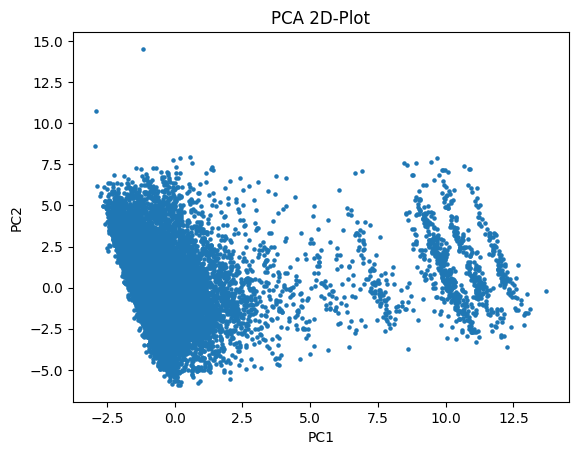

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D-Plot")
plt.show()


NameError: name 'dim_reduction' is not defined

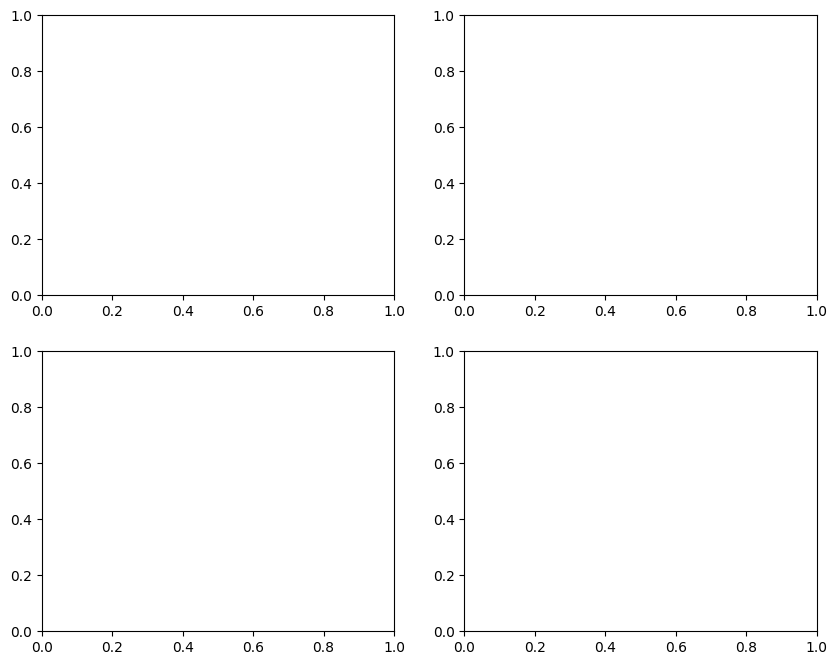

In [8]:
import seaborn as sns

fig = plt.figure(figsize=(10,8))
axes = [fig.add_subplot(220+i+1) for i in range(4)]

for i,ax in enumerate(axes):
    sns.heatmap(dim_reduction.components_[i].reshape(8,8), 
                square=True, ax=ax, 
                vmax = 0.30, vmin=-0.30)
    ax.set_title('Hauptkomponente '+str(i))
   
plt.show()